# **Pré-processamento**


**Importação e Instalação** 


In [34]:
!pip install seaborn --quiet
!pip install scikit-learn --quiet
!pip install statsmodels --quiet

In [35]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [36]:
df = pd.read_csv('dados_fundo_do_amanha_evcomx.csv', sep=';')

In [37]:
pd.set_option('display.max_columns', 22)
df.head(n=10)

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
1,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1652,1672,1543.0,1555.0
2,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1650,1670,1543.0,1555.0
3,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1655,1672,1543.0,1555.0
4,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
5,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1651,1672,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
7,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1681,1678,1543.0,1547.0
8,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1680,1678,1543.0,1547.0
9,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1677,1678,1543.0,1547.0


**Tamanho**

In [38]:
df.shape

(48658, 22)

**Tipo**

In [39]:
df.dtypes

corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
velocidadeobjetivada     float64
velocidadereal           float64
sugestaomodelolegado       int64
temperaturasaidafp         int64
temperaturaobjetivada    float64
temperaturamediareal     float64
dtype: object

**Percentual de dados faltantes por coluna**



In [40]:
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().sum() / len(df['corrida'])) * 100
print(faltantes_percentual)

corrida                  0.000000
secao                    0.000000
acoatual                 0.000000
qualidade                0.000000
al_min                   0.000000
c_min                    0.000000
c_max                    0.000000
n_min                    0.000000
s_min                    0.000000
sequencia                0.000000
sequenciatotal           0.000000
panela                   0.000000
vidapanela               0.000000
tempociclo               0.000000
tempovacuototal          0.000000
temperaturaliquidus      0.000000
velocidadeobjetivada     0.000000
velocidadereal           0.000000
sugestaomodelolegado     0.000000
temperaturasaidafp       0.000000
temperaturaobjetivada    0.000000
temperaturamediareal     0.024662
dtype: float64


**Exclusão das linhas com valores nulos**

In [41]:
#Como a porcentagem de dados faltantes é irrelevante(menos de 5%) apenas descartamos os valores NAN e/ou nulos

df = df.dropna()

**Removendo colunas duplicadas**

In [42]:
#Removemos as colunas duplicadas baseado na coluna corrida e mantendo a mais recente conforme instruido

df = df.drop_duplicates(subset=['corrida'], keep='first')
df.shape

(7482, 22)

**Verificando Valores unicos**

In [43]:
valores_unicos = df.nunique()

print(valores_unicos)

corrida                  7482
secao                       2
acoatual                 3503
qualidade                 253
al_min                      4
c_min                     121
c_max                     126
n_min                       3
s_min                      29
sequencia                  11
sequenciatotal             11
panela                     12
vidapanela                 76
tempociclo               3902
tempovacuototal            24
temperaturaliquidus        49
velocidadeobjetivada       13
velocidadereal            115
sugestaomodelolegado      134
temperaturasaidafp        138
temperaturaobjetivada      59
temperaturamediareal      105
dtype: int64


# Separando variaveis em numericas ou categoricas 

In [44]:
# Converter colunas de identificação e restrição para o tipo de dado correto (strings)
id_cols = ['acoatual', 'qualidade', 'panela']
for col in id_cols:
    df[col] = df[col].astype(str)

num_cols = ['al_min', 'c_min', 'c_max', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 
            'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 
            'velocidadeobjetivada', 'sugestaomodelolegado', 
            'temperaturasaidafp', 'temperaturaobjetivada']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' substitui erros por NaN
real_cols = ['temperaturamediareal', 'velocidadereal']
for col in real_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# **Análise exploratória**

In [45]:
df.head()

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


# Comportamento de Tsaidafp

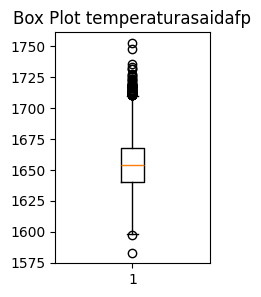

In [46]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturasaidafp)
plt.title("Box Plot temperaturasaidafp")
plt.show()

# Comportamento de Temperaturaobjetivada

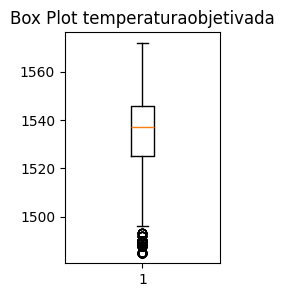

In [47]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturaobjetivada)
plt.title("Box Plot temperaturaobjetivada")
plt.show()

# Comportamento de VidaPanela

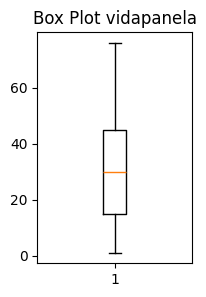

In [48]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.vidapanela)
plt.title("Box Plot vidapanela")
plt.show()

<Axes: >

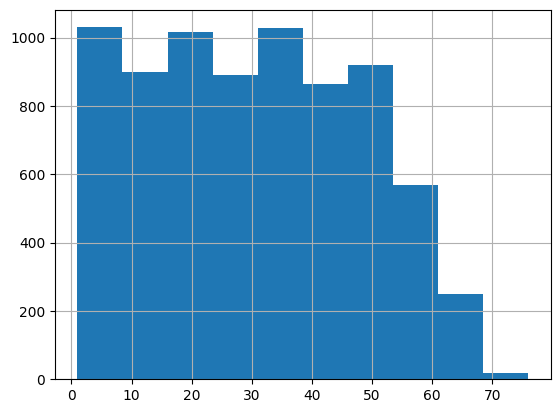

In [49]:
df.vidapanela.hist()
# fazer dispersao 

# Comportamento de Secao

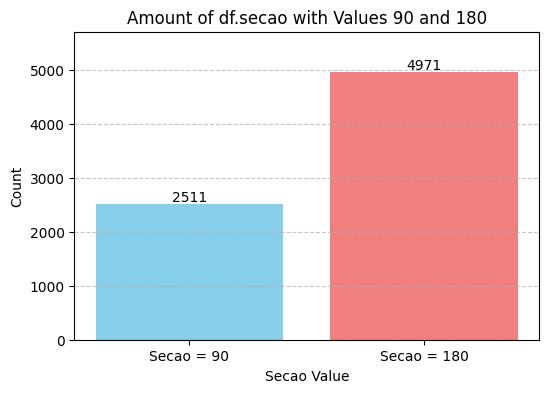

In [50]:
try:
    counts = df['secao'].value_counts()
    count_90 = counts.get(90)
    count_180 = counts.get(180)

    labels = ['Secao = 90', 'Secao = 180']
    amounts = [count_90, count_180]

    # Create the bar chart
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, amounts, color=['skyblue', 'lightcoral'])

    for bar in bars:
        yval = bar.get_height()
  
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom')

    plt.title('Amount of df.secao with Values 90 and 180')
    plt.xlabel('Secao Value')
    plt.ylabel('Count')

    plt.ylim(0, max(amounts) * 1.15 if amounts else 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show() 

except Exception as e:
    print(f"An error occurred: {e}")
    plt.show()
    plt.clf()
    

In [51]:
# Calculate mean temperaturamediareal for secao 90 and 180
mean_90 = df.loc[df['secao'] == 90, 'temperaturaobjetivada'].mean()
mean_180 = df.loc[df['secao'] == 180, 'temperaturaobjetivada'].mean()

df.groupby('secao')['temperaturaobjetivada'].describe()

,count,mean,std,min,25%,50%,75%,max
secao,,,,,,,,
90.0,2511.0,1537.493429,11.391120,1497.0,1530.0,1537.0,1549.0,1557.0
180.0,4971.0,1531.686783,16.047711,1485.0,1525.0,1535.0,1546.0,1572.0


Removi a variavel secao devido a analise feita acima

In [52]:
df = df.drop(columns=['secao'])

# Comportamento de aluminio minimo

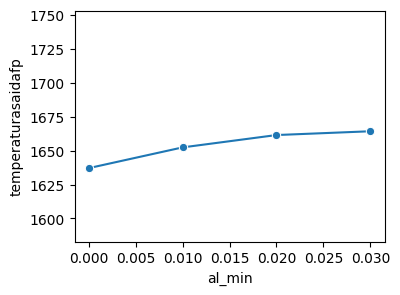

In [53]:
plt.figure(figsize=(4, 3))
sns.lineplot(data=df, x='al_min', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.show()

# Comportamento TObjetivada


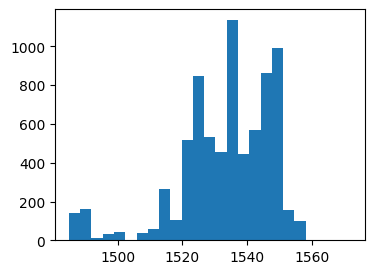

In [54]:
plt.figure(figsize=(4, 3))
plt.hist(df['temperaturaobjetivada'], bins=25)
plt.show()

# Análises do modelo atual em relação a algumas variáveis 

In [55]:
df = df[df['sugestaomodelolegado'] >= 200].copy()

Modelolegado x Tmediareal

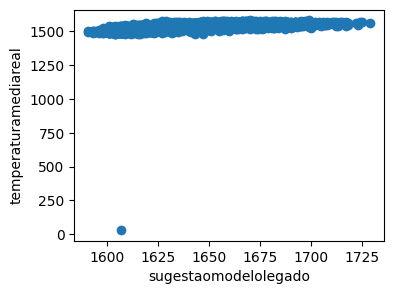

In [56]:
plt.figure(figsize=(4, 3))
plt.scatter(df.sugestaomodelolegado, df.temperaturamediareal)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturamediareal')
plt.show()
#o gráfico mostra que o modelo legado está muito disperso em relação a tmediareal

Modelolegado x Tobjetivada

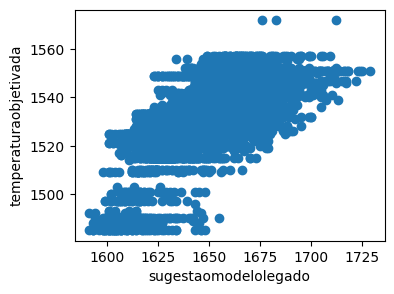

In [57]:
plt.figure(figsize=(4, 3))
plt.scatter(df.sugestaomodelolegado, df.temperaturaobjetivada)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturaobjetivada')
plt.show()
#o gráfico mostra que o modelo legado está muito disparso em relação a temperatura objetivada

In [58]:
#A variável corrida só serviu para limpar valores duplicados, não tem mais utilidade, deve ser removida

df = df.drop(columns=['corrida'])
df.shape

(7478, 20)

# Comportamento da variável target e relação com outras

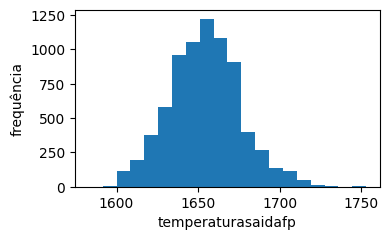

In [59]:
plt.figure(figsize=(4,2.5))
plt.hist(df['temperaturasaidafp'], bins=20)
plt.xlabel('temperaturasaidafp')
plt.ylabel('frequência')
plt.tight_layout()
plt.show()

In [60]:
df['temperaturasaidafp'].describe()

count    7478.000000
mean     1653.995855
std        21.715515
min      1583.000000
25%      1640.000000
50%      1654.000000
75%      1668.000000
max      1753.000000
Name: temperaturasaidafp, dtype: float64

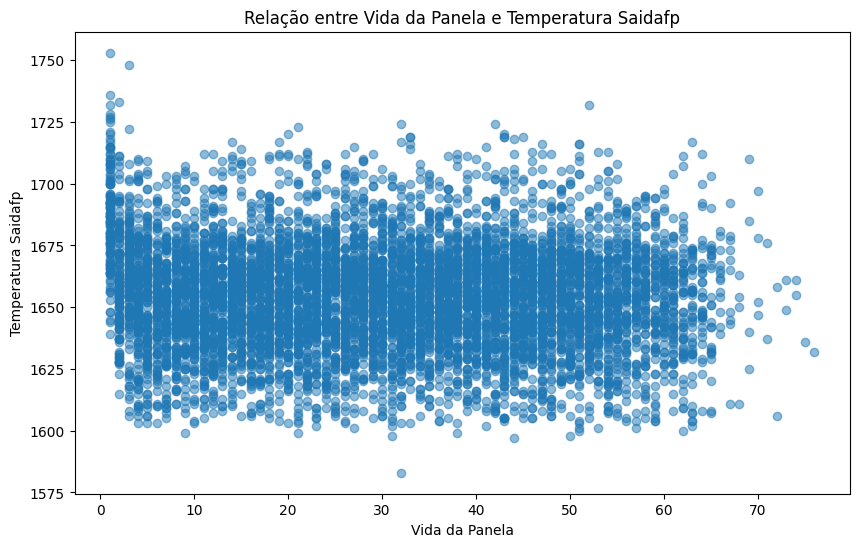

In [61]:
df = df[df.temperaturasaidafp > 500]
plt.figure(figsize=(10, 6))
plt.scatter(df['vidapanela'], df['temperaturasaidafp'], alpha=0.5)
plt.title('Relação entre Vida da Panela e Temperatura Saidafp')
plt.xlabel('Vida da Panela')
plt.ylabel('Temperatura Saidafp')
plt.show()

**Comportamento al_min x target**

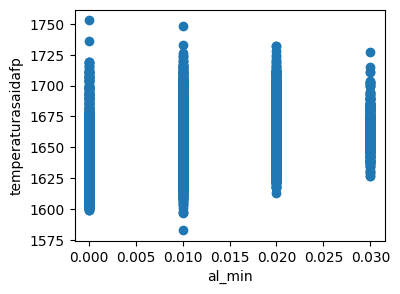

In [62]:
plt.figure(figsize=(4, 3))
plt.scatter(df['al_min'], df['temperaturasaidafp'])
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.show()

# **Avaliação de desempenho do modelo legado**

**Verificando o uso ou não uso do modelo pelos operadores**

In [63]:
df['usage'] = df.apply(
    lambda row: 'usou' if row['sugestaomodelolegado']-row['temperaturasaidafp'] >=-5
    and row['sugestaomodelolegado'] - row['temperaturasaidafp'] <=5
    else 'Naousou',axis=1)
display(df[['temperaturasaidafp', 'sugestaomodelolegado', 'usage']].head())

,temperaturasaidafp,sugestaomodelolegado,usage
0,1670,1648,Naousou
6,1678,1674,usou
28,1672,1651,Naousou
36,1674,1667,Naousou
40,1662,1687,Naousou


In [64]:
# Calculate the percentage of 'usou' and 'Naousou' in the 'usage' column
usage_percentage = df['usage'].value_counts(normalize=True) * 100

# Print the percentages
print("Porcentagem de 'usou' e 'Naousou':")
print(usage_percentage)

Porcentagem de 'usou' e 'Naousou':
usage
usou       56.833378
Naousou    43.166622
Name: proportion, dtype: float64


**Verificando a porcentagem de acerto do modelo legado**

In [65]:
df['diferenca'] = df['sugestaomodelolegado'] - df['temperaturasaidafp']
display(df[['sugestaomodelolegado', 'temperaturasaidafp', 'diferenca']].head())

,sugestaomodelolegado,temperaturasaidafp,diferenca
0,1648,1670,-22
6,1674,1678,-4
28,1651,1672,-21
36,1667,1674,-7
40,1687,1662,25


In [66]:
df['nova_temperatura'] = df['diferenca'] + df['temperaturamediareal']
display(df[['diferenca', 'temperaturamediareal', 'nova_temperatura']].head())

,diferenca,temperaturamediareal,nova_temperatura
0,-22,1555.0,1533.0
6,-4,1547.0,1543.0
28,-21,1556.0,1535.0
36,-7,1540.0,1533.0
40,25,1550.0,1575.0


# Função para marcar temperatura

In [67]:
def check_temperature_range(row):
    nova_temperatura = row['nova_temperatura']
    temperatura_objetivada = row['temperaturaobjetivada']
    if (nova_temperatura >= temperatura_objetivada - 5) and (nova_temperatura <= temperatura_objetivada + 10):
        return 'acerto'
    elif nova_temperatura < (temperatura_objetivada - 5):
        return 'erro para baixo'
    else: 
        return 'erro para cima'

# Criação de novos DataFrames


In [68]:
df_usou = df[df['usage'] == 'usou'].copy()
df_usou['flag_nova_temperatura'] = df_usou.apply(check_temperature_range, axis=1)
display(df_usou[['nova_temperatura', 'temperaturaobjetivada', 'flag_nova_temperatura']].head())
df_usou.shape

,nova_temperatura,temperaturaobjetivada,flag_nova_temperatura
6,1543.0,1543.0,acerto
49,1542.0,1537.0,acerto
60,1536.0,1537.0,acerto
63,1534.0,1537.0,acerto
73,1539.0,1537.0,acerto


(4250, 24)

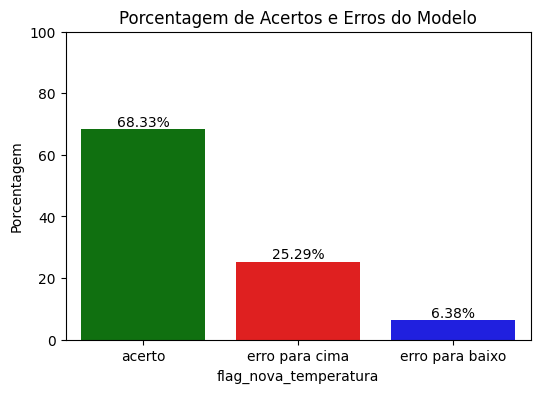

In [69]:
flag_counts = df_usou['flag_nova_temperatura'].value_counts(normalize=True) * 100

# Create a bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette=['green', 'red', 'blue'], hue=flag_counts.index, legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros do Modelo')
plt.ylim(0, 100)
plt.show()

**Criando df com os valores que nao foi considerado o modelolegado**

In [70]:
df_operadores = df[df['usage'] != 'usou'].copy()  
df_operadores.shape

(3228, 23)

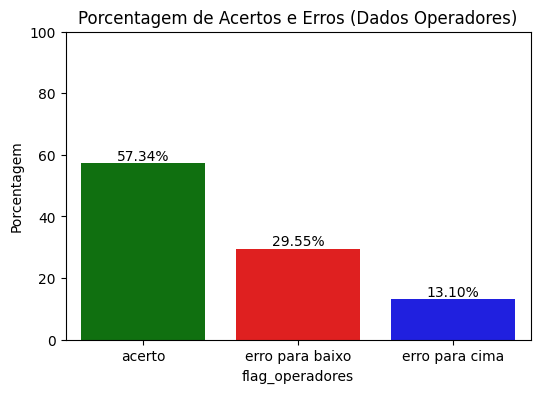

In [71]:
df_operadores['flag_operadores'] = df_operadores.apply(check_temperature_range, axis=1)
flag_counts_operadores = df_operadores['flag_operadores'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts_operadores.index, y=flag_counts_operadores.values, palette=['green', 'red','blue'], hue=flag_counts_operadores.index, legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros (Dados Operadores)')
plt.ylim(0, 100)
plt.show()

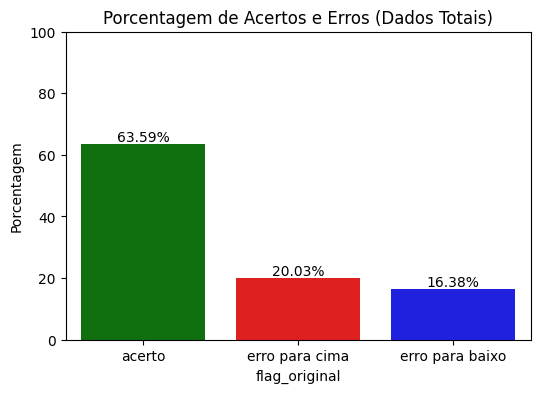

In [72]:
df_original = df.copy()
df_original['flag_original'] = df_original.apply(check_temperature_range, axis=1)
flag_counts_original = df_original['flag_original'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts_original.index, y=flag_counts_original.values, palette=['green', 'red','blue'], hue=flag_counts_original.index, legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros (Dados Totais)')
plt.ylim(0, 100)
plt.show()

# Limpando os DF's das colunas criadas e de colunas que nao poderão ser usadas


In [73]:
df = df.drop(columns=['usage', 'diferenca', 'nova_temperatura','temperaturamediareal','velocidadereal'])
df_operadores = df_operadores.drop(columns=['flag_operadores','usage','diferenca','nova_temperatura','temperaturamediareal','velocidadereal'])
df_original = df_original.drop(columns=['flag_original','usage','diferenca','nova_temperatura','temperaturamediareal','velocidadereal'])

# Avaliando a correlação das variáveis

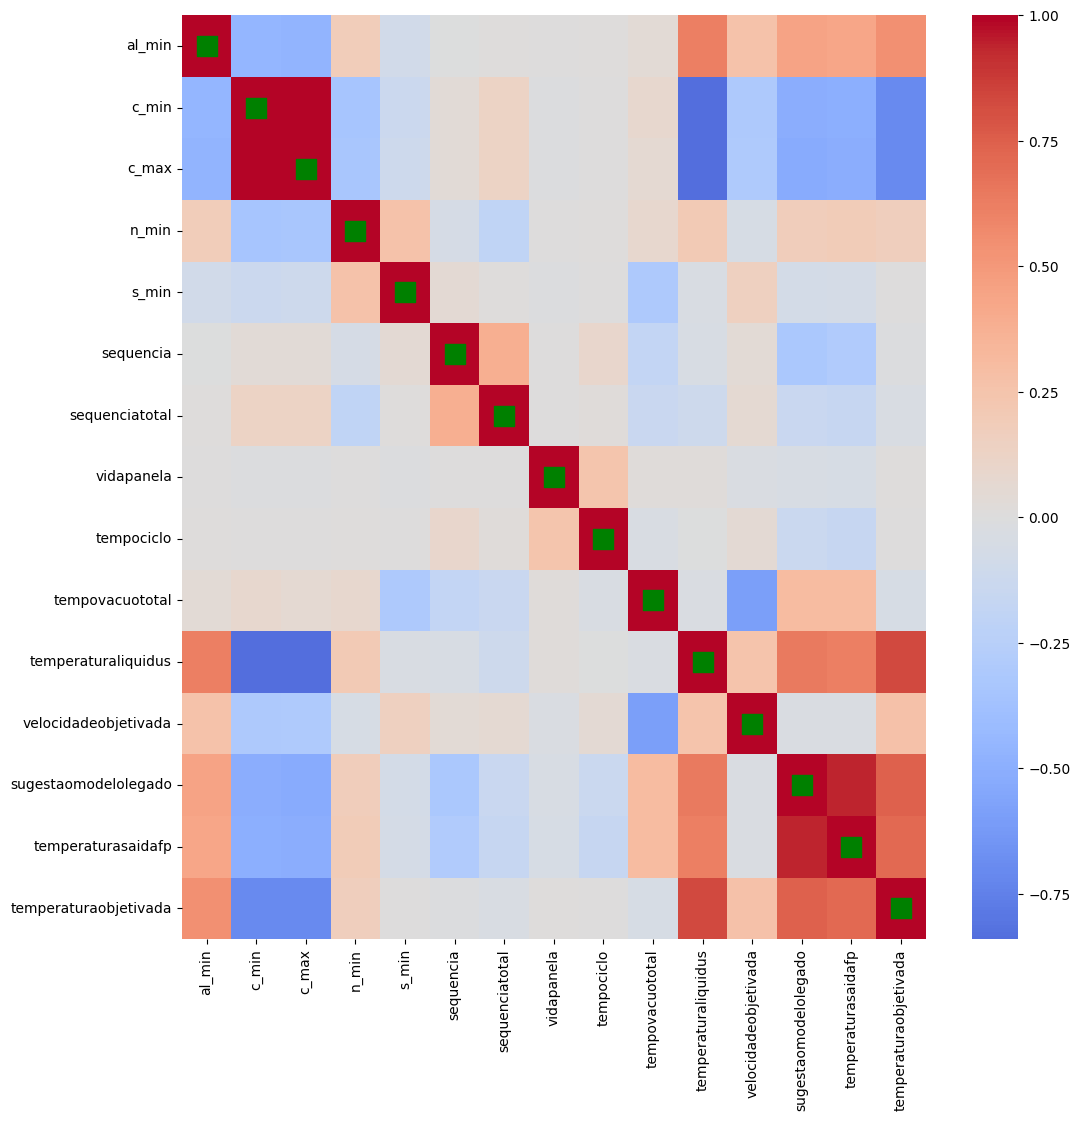

In [74]:
target = 'temperaturasaidafp'
corr = df[num_cols].corr(method='spearman')

plt.figure(figsize=(12,12))
ax = sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, fmt=".2f")

# Pegar o tamanho da matriz
n = corr.shape[0]

# Plotar uma diagonal verde (usando scatter)
ax.scatter(
    x=np.arange(0.5, n),  # posições no eixo x
    y=np.arange(0.5, n),  # posições no eixo y
    c="green", s=200, marker="s"  # quadrados verdes grandes
)

In [75]:
corr.corr(method='spearman')

,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada
al_min,1.000000,-0.857143,-0.860714,0.585714,-0.067857,-0.582143,-0.596429,0.014286,-0.289286,0.150000,0.917857,0.532143,0.878571,0.875000,0.875000
c_min,-0.857143,1.000000,0.996429,-0.760714,-0.178571,0.575000,0.685714,0.078571,0.350000,-0.021429,-0.964286,-0.557143,-0.878571,-0.875000,-0.975000
c_max,-0.860714,0.996429,1.000000,-0.757143,-0.175000,0.571429,0.682143,0.082143,0.339286,-0.025000,-0.967857,-0.553571,-0.882143,-0.878571,-0.978571
n_min,0.585714,-0.760714,-0.757143,1.000000,0.278571,-0.550000,-0.789286,-0.032143,-0.367857,0.182143,0.660714,0.239286,0.700000,0.707143,0.635714
s_min,-0.067857,-0.178571,-0.175000,0.278571,1.000000,0.467857,0.125000,-0.021429,0.492857,-0.710714,0.039286,0.496429,-0.117857,-0.114286,0.171429
sequencia,-0.582143,0.575000,0.571429,-0.550000,0.467857,1.000000,0.903571,0.128571,0.757143,-0.785714,-0.632143,0.264286,-0.803571,-0.800000,-0.514286
sequenciatotal,-0.596429,0.685714,0.682143,-0.789286,0.125000,0.903571,1.000000,-0.017857,0.567857,-0.621429,-0.703571,0.150000,-0.825000,-0.828571,-0.607143
vidapanela,0.014286,0.078571,0.082143,-0.032143,-0.021429,0.128571,-0.017857,1.000000,0.428571,-0.064286,0.014286,-0.075000,-0.117857,-0.121429,-0.053571
tempociclo,-0.289286,0.350000,0.339286,-0.367857,0.492857,0.757143,0.567857,0.428571,1.000000,-0.607143,-0.325000,0.242857,-0.550000,-0.553571,-0.239286
tempovacuototal,0.150000,-0.021429,-0.025000,0.182143,-0.710714,-0.785714,-0.621429,-0.064286,-0.607143,1.000000,0.110714,-0.728571,0.357143,0.360714,-0.025000


In [76]:
# Esse é o código que gera a tabela que eu preciso:
target_correlations = corr['temperaturasaidafp'].sort_values(ascending=False)
print(target_correlations)

temperaturasaidafp       1.000000
sugestaomodelolegado     0.939138
temperaturaobjetivada    0.718598
temperaturaliquidus      0.619656
al_min                   0.437008
tempovacuototal          0.309555
n_min                    0.194026
velocidadeobjetivada    -0.022466
vidapanela              -0.053437
s_min                   -0.070014
tempociclo              -0.157441
sequenciatotal          -0.161977
sequencia               -0.289083
c_min                   -0.501360
c_max                   -0.512846
Name: temperaturasaidafp, dtype: float64


# Juntando variaveis correlacionadas e criando adicionais

In [79]:
df['c_mean'] = (df['c_min'] + df['c_max']) / 2
df_operadores['c_mean'] = (df_operadores['c_min'] + df_operadores['c_max']) / 2
df_original['c_mean'] = (df_original['c_min'] + df_original['c_max']) / 2
df['T_Liquid_Desvio'] = df['temperaturaobjetivada'] - df['temperaturaliquidus']
df_operadores['T_Liquid_Desvio'] = df_operadores['temperaturaobjetivada'] - df_operadores['temperaturaliquidus']
df_original['T_Liquid_Desvio'] = df_original['temperaturaobjetivada'] - df_original['temperaturaliquidus']  
df['Desvio_Legado_Target'] = df['sugestaomodelolegado'] - df['temperaturaobjetivada']
df_operadores['Desvio_Legado_Target'] = df_operadores['sugestaomodelolegado'] - df_operadores['temperaturaobjetivada']
df_original['Desvio_Legado_Target'] = df_original['sugestaomodelolegado'] - df_original['temperaturaobjetivada']
df['Tempo_Sequencia'] = df['tempociclo'] * df['sequencia']
df_operadores['Tempo_Sequencia'] = df_operadores['tempociclo'] * df_operadores['sequencia']
df_original['Tempo_Sequencia'] = df_original['tempociclo'] * df_original['sequencia']

# Removendo colunas para filtragem do modelo